# 1. Análisis Exploratorio de Datos (EDA)

Este notebook realiza un análisis exploratorio del dataset `hyundai_maintenance.csv`. El objetivo es entender la estructura de los datos, sus distribuciones, y las relaciones entre las variables antes de proceder al preprocesamiento y modelado.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Cargar el Dataset

Cargamos el archivo `hyundai_maintenance.csv`. Si el archivo no se encuentra, mostraremos un mensaje de error con instrucciones para descargarlo.

In [2]:
# Definir rutas
data_path = '../data/cars_hyundai.csv'
figures_path = '../figures'

# Crear el directorio de figuras si no existe
if not os.path.exists(figures_path):
    os.makedirs(figures_path)

# Cargar el dataset
try:
    df = pd.read_csv(data_path)
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'cars_hyundai.csv' en la carpeta 'ml/data/'.")
    print("Por favor, asegúrate de que el dataset esté en la ubicación correcta.")
    df = None

if df is not None:
    # Renombrar columnas para facilitar el acceso
    df.columns = ['engine_temp', 'brake_pad_thickness', 'tire_pressure', 'maintenance_type', 'anomaly']
    print("Columnas renombradas para mayor comodidad.")

Dataset cargado exitosamente.
Columnas renombradas para mayor comodidad.


## Análisis Inicial

Mostramos la forma del dataframe, los tipos de datos de cada columna y las primeras 5 filas para tener una visión general.

In [3]:
if df is not None:
    print(f"Forma del dataset: {df.shape}")
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nPrimeras 5 filas:")
    display(df.head())

Forma del dataset: (1100, 5)

Tipos de datos:
engine_temp            float64
brake_pad_thickness    float64
tire_pressure          float64
maintenance_type        object
anomaly                  int64
dtype: object

Primeras 5 filas:


,engine_temp,brake_pad_thickness,tire_pressure,maintenance_type,anomaly
0,81.022390,7.984018,35.964546,Repair,0
1,98.076029,10.718692,32.143593,Routine Maintenance,1
2,81.205967,10.983070,31.058628,Routine Maintenance,1
3,86.081294,7.045311,28.539264,Repair,0
4,93.496568,9.948991,33.599560,Component Replacement,1


## Verificación de Valores Nulos y Estadísticas Descriptivas

In [4]:
if df is not None:
    print("Valores nulos por columna:")
    print(df.isnull().sum())
    
    print("\nEstadísticas descriptivas:")
    display(df.describe().T)

Valores nulos por columna:
engine_temp            0
brake_pad_thickness    0
tire_pressure          0
maintenance_type       0
anomaly                0
dtype: int64

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
engine_temp,1100.0,90.108394,5.797819,80.025954,84.868469,90.461940,94.907044,99.980940
brake_pad_thickness,1100.0,8.986553,1.737784,6.001549,7.418846,9.039794,10.423316,11.994006
tire_pressure,1100.0,33.090653,2.876990,28.009132,30.670348,33.169252,35.625786,37.992710
anomaly,1100.0,0.500909,0.500227,0.000000,0.000000,1.000000,1.000000,1.000000


## Visualización de Datos

### Histogramas de Variables Numéricas
Analizamos la distribución de las variables continuas.

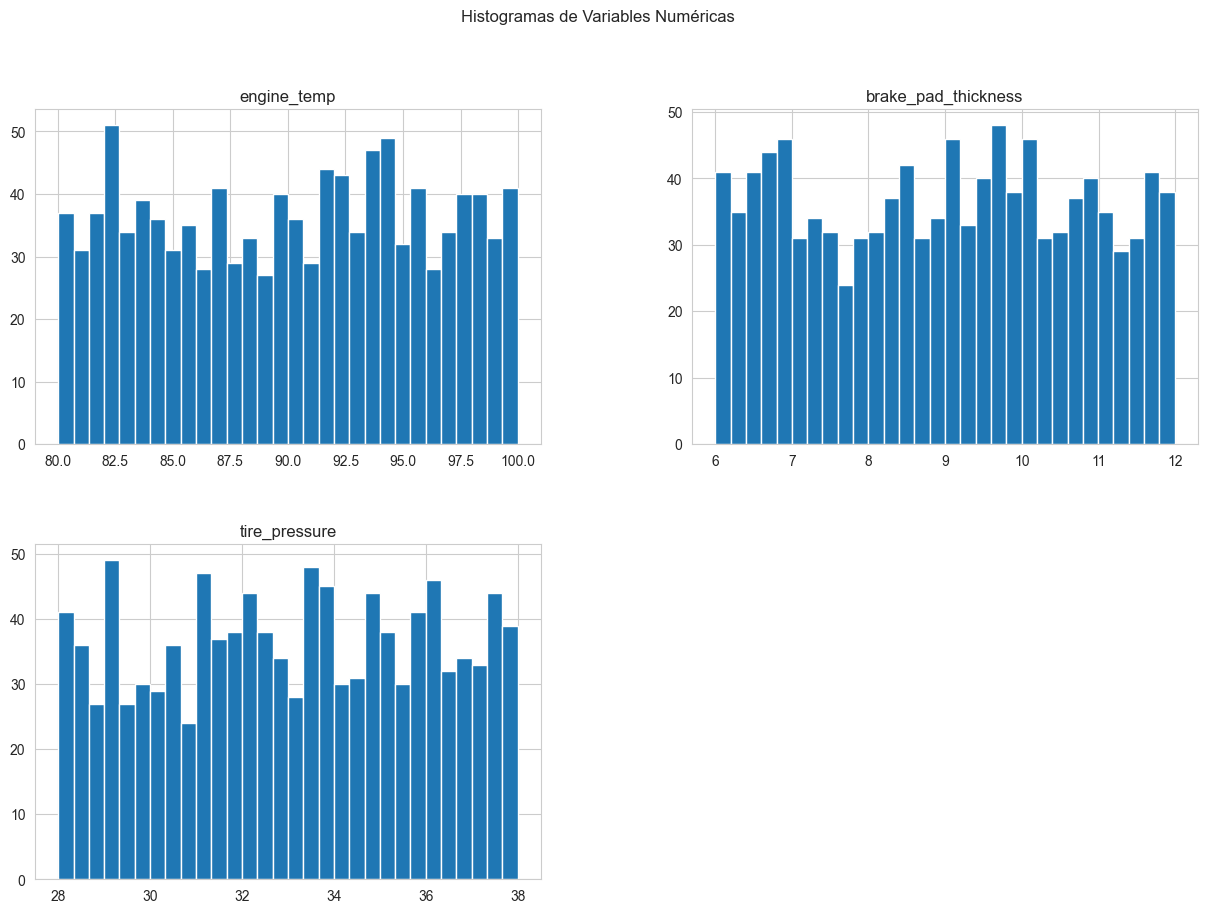

In [5]:
if df is not None:
    numerical_features = ['engine_temp', 'brake_pad_thickness', 'tire_pressure']
    df[numerical_features].hist(bins=30, figsize=(15, 10))
    plt.suptitle("Histogramas de Variables Numéricas")
    plt.savefig(os.path.join(figures_path, 'histograms.png'))
    plt.show()

### Distribución de la Variable Objetivo (`anomaly`)

Es crucial verificar si las clases están balanceadas. Un desbalance puede afectar el entrenamiento y la evaluación del modelo.

/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


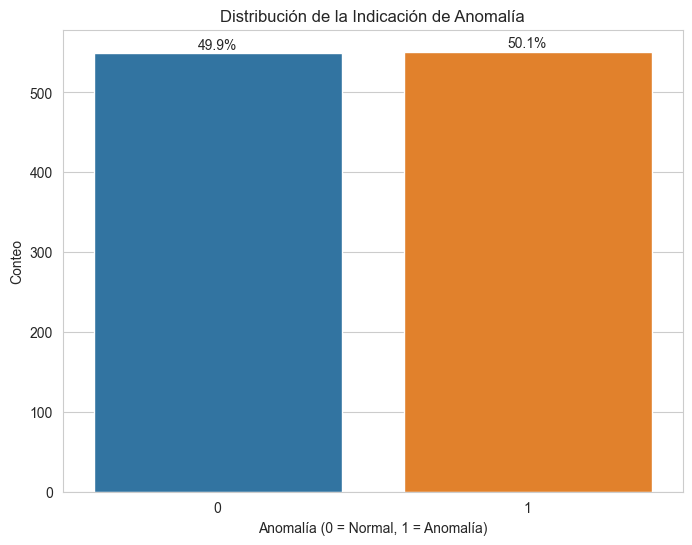

anomaly
1    0.500909
0    0.499091
Name: proportion, dtype: float64


In [6]:
if df is not None:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='anomaly', data=df)
    plt.title('Distribución de la Indicación de Anomalía')
    plt.xlabel('Anomalía (0 = Normal, 1 = Anomalía)')
    plt.ylabel('Conteo')
    
    # Añadir porcentajes
    total = len(df)
    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 5,
                f'{height/total:.1%}',
                ha="center")
    
    plt.savefig(os.path.join(figures_path, 'anomaly_distribution.png'))
    plt.show()
    
    print(df['anomaly'].value_counts(normalize=True))

### Matriz de Correlación

Para entender las relaciones lineales entre las variables numéricas.

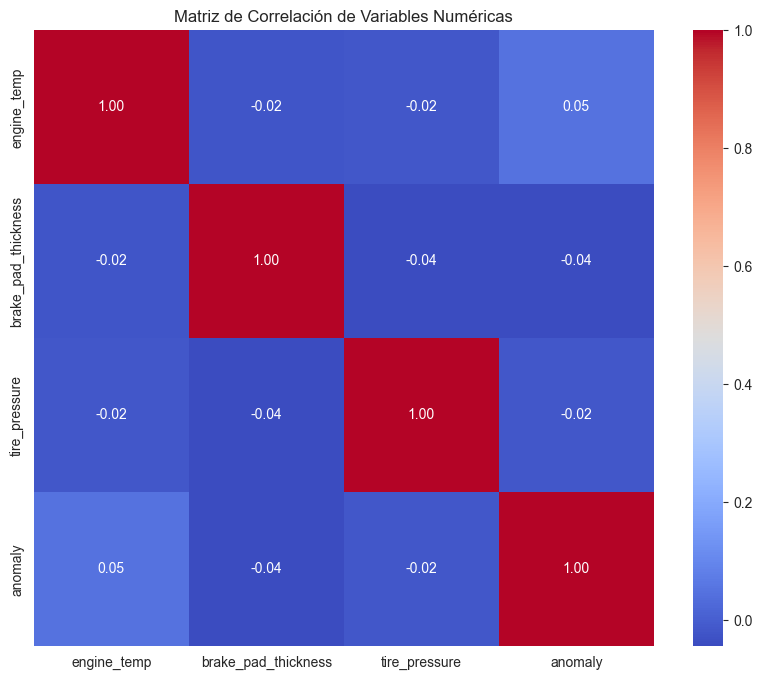

In [7]:
if df is not None:
    # Seleccionar solo columnas numéricas para la correlación
    numeric_df = df.select_dtypes(include=np.number)
    
    plt.figure(figsize=(10, 8))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación de Variables Numéricas')
    plt.savefig(os.path.join(figures_path, 'correlation_matrix.png'))
    plt.show()

### Boxplots por Clase (Normal vs. Anomalía)

Comparamos las distribuciones de cada variable numérica para los casos normales y anómalos.

/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


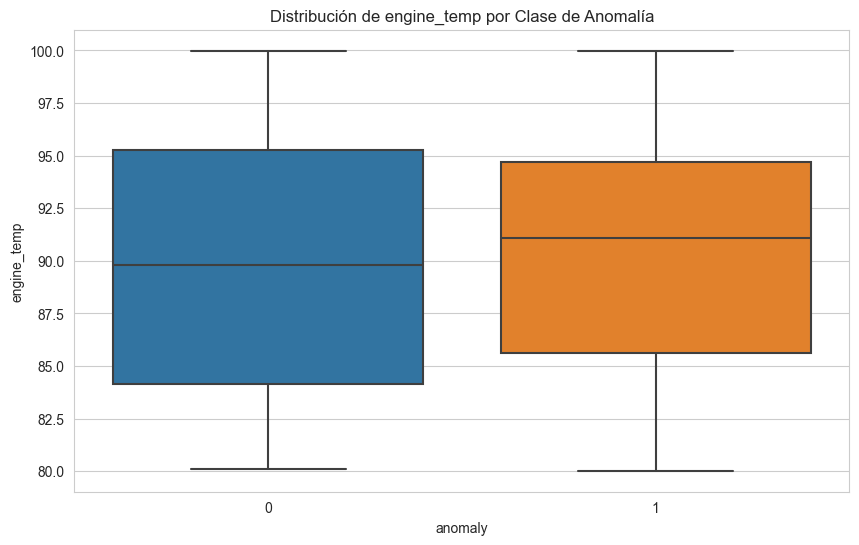

/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


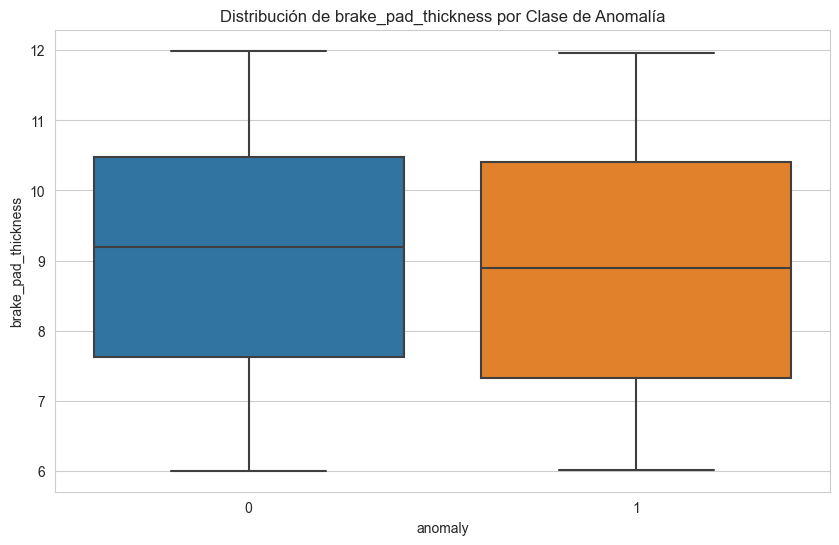

/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/matiasalarcon/vehicle-predictive-maintenance/ml/.venv310/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


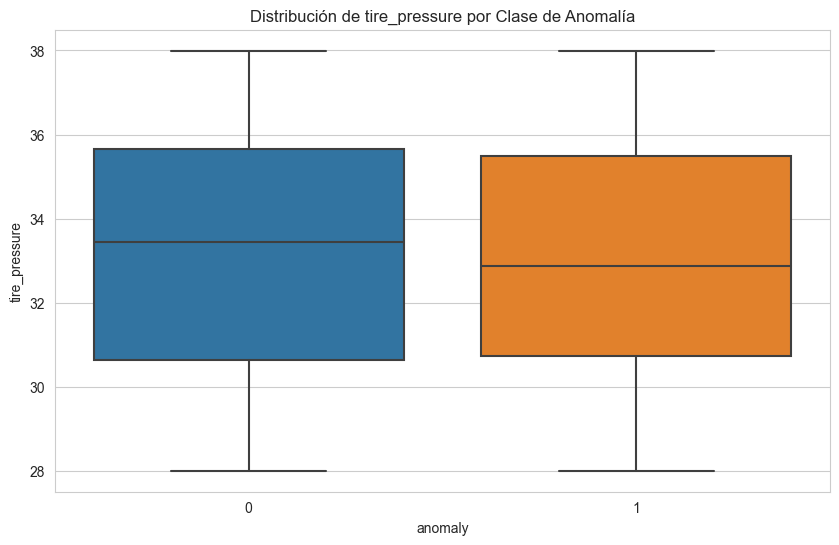

In [8]:
if df is not None:
    for feature in numerical_features:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='anomaly', y=feature, data=df)
        plt.title(f'Distribución de {feature} por Clase de Anomalía')
        plt.savefig(os.path.join(figures_path, f'boxplot_{feature}.png'))
        plt.show()